# Michaelis-Menten kinetics, double binding 

This notebook explores several models of AMPK activation. 

Nathaniel Linden (UCSD MAE) - Mar  2023

In [1]:
import sunode
import pymc as pm
import matplotlib.pyplot as plt
import numpy as np
import sympy as sym
import sys
from sympy import init_printing
init_printing()
sys.path.insert(0, '../odes')
import ampk_MM_double_mech as model
from get_left_nullspace_vecs_invariants import get_left_nullspace_vecs_invariants as left_ns
%matplotlib inline

WARNING (aesara.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


We will start with the relevant initial conditions and parameters from Coccimiglio et al.
Parameter values are taken from Sup Table D col "pre-calibration value," thus they are from Xiao et al. Nature 2011.
Initial conditions are taken from Sup Table 

Parameters not included in that model are assigned arbitrarily. 

**Note that this simulation just tests the machinery of the model and simulation!**

In [2]:
# First we want to check that the model obeys proper conservation of mass
# use our function for this
rhs, sym_fluxes = model.ampk_MM_double_mech_RHS_sympyFluxVars()
stoich, left_ns_vecs, invars = left_ns(rhs, sym_fluxes)
for idx, invariant in zip(range(len(invars)), invars):
    print('The {} invariant is:'.format(idx))
    sym.pprint(invariant, use_unicode=True)
    print('\n')

The 0 invariant is:
[-ADP + ADPAMPK + ADPpAMPK - AMP + AMPAMPK + 2⋅AMPK + AMPpAMPK - ATP + ATPAMPK
 + ATPpAMPK + 2⋅pAMPK]


The 1 invariant is:
[ADP + ADPADPAMPK + ADPADPpAMPK + ADPATPAMPK + ADPATPpAMPK + AMP + AMPADPAMPK 
+ AMPADPpAMPK + AMPAMPAMPK + AMPAMPpAMPK + AMPATPAMPK + AMPATPpAMPK - AMPK + A
TP + ATPATPAMPK + ATPATPpAMPK - pAMPK]


The 2 invariant is:
[AMPKAR + pAMPKAR]




In [9]:
# 0 + 1
print('Invariant {i} + {j}:'.format(i=0, j=1))
sym.pprint(invars[0]+invars[1], use_unicode=True)
print('\n')

# 2*(1 + 0.5 0)
print('2 * Invariant {i} + Invariant {j}:'.format(i=1, j=0))
sym.pprint(2*invars[1]+ invars[0], use_unicode=True)
print('\n')

Invariant 0 + 1:
[ADPADPAMPK + ADPADPpAMPK + ADPAMPK + ADPATPAMPK + ADPATPpAMPK + ADPpAMPK + AM
PADPAMPK + AMPADPpAMPK + AMPAMPAMPK + AMPAMPK + AMPAMPpAMPK + AMPATPAMPK + AMP
ATPpAMPK + AMPK + AMPpAMPK + ATPAMPK + ATPATPAMPK + ATPATPpAMPK + ATPpAMPK + p
AMPK]


2 * Invariant 1 + Invariant 0:
[ADP + 2⋅ADPADPAMPK + 2⋅ADPADPpAMPK + ADPAMPK + 2⋅ADPATPAMPK + 2⋅ADPATPpAMPK +
 ADPpAMPK + AMP + 2⋅AMPADPAMPK + 2⋅AMPADPpAMPK + 2⋅AMPAMPAMPK + AMPAMPK + 2⋅AM
PAMPpAMPK + 2⋅AMPATPAMPK + 2⋅AMPATPpAMPK + AMPpAMPK + ATP + ATPAMPK + 2⋅ATPATP
AMPK + 2⋅ATPATPpAMPK + ATPpAMPK]




In [10]:
# load the necessary dictionaries
params = model.ampk_MM_double_mech_get_params()
states = model.ampk_MM_double_mech_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=model.ampk_MM_double_mech_RHS,
    # specify variables to take gradients wrt
    derivative_params=(),
)

# set up solver
solver = sunode.solver.Solver(problem, solver='BDF')

# Initial conditions
y0 = np.zeros((), dtype=problem.state_dtype)
# free adenine nucleotides
y0['AMP'] = 2e-5   # 'AMP' mM
y0['ATP'] = 1.3e-1 # 'ADP mM
y0['ADP'] = 8.2   # 'ATP mM
# # free AMPK
y0['AMPK'] = 6   # 'AMPK mM
y0['pAMPK'] = 0   # 'pAMPK mM
# # single AXP-AMPK complexes
y0['AMP_AMPK'] = 0  # 'AMP_AMPK mM
y0['ADP_AMPK'] = 0   # 'ADP_AMPK mM
y0['ATP_AMPK'] = 0   # 'ATP_AMPK mM
# # single AXP-pAMPK complexes
y0['AMP_pAMPK'] = 0   # 'AMP_pAMPK mM
y0['ADP_pAMPK'] = 0   # 'ADP_pAMPK mM
y0['ATP_pAMPK'] = 0   # 'ATP_pAMPK mM
# # double AXP-AMPK complexes
y0['AMP_AMP_AMPK'] = 0   # 'AMP_AMP_AMPK mM
y0['AMP_ADP_AMPK'] = 0   # 'AMP_ADP_AMPK mM
y0['AMP_ATP_AMPK'] = 0   # 'AMP_ATP_AMPK mM
y0['ADP_ADP_AMPK'] = 0   # 'ADP_ADP_AMPK mM
y0['ADP_ATP_AMPK'] = 0   # 'ADP_ATP_AMPK mM
y0['ATP_ATP_AMPK'] = 0   # 'ATP_ATP_AMPK mM
# # double AXP-pAMPK complexes
y0['AMP_AMP_pAMPK'] = 0   # 'AMP_AMP_pAMPK mM
y0['AMP_ADP_pAMPK'] = 0   # 'AMP_ADP_pAMPK mM
y0['AMP_ATP_pAMPK'] = 0   # 'AMP_ATP_pAMPK mM
y0['ADP_ADP_pAMPK'] = 0   # 'ADP_ADP_pAMPK mM
y0['ADP_ATP_pAMPK'] = 0   # 'ADP_ATP_pAMPK mM
y0['ATP_ATP_pAMPK'] = 0   # 'ATP_ATP_pAMPK mM
# # free AMPKAR
y0['AMPKAR'] = 3.0   # 'AMPKAR mM
y0['pAMPKAR'] = 0   # pAMPKAR

 # evaluate the solution at these times
tvals = np.linspace(0, 300, 500)

 # set the parameters
 # TODO: MORE RESEARCH ON THE PARAMETERS!
solver.set_params_dict({
    'kOnAMP': 1, # 1/(mM s) - from Coccimiglio 
    'kOffAMP': 2.5e-3, # 1/s - from Coccimiglio 
    'kOnADP': 1 , # 1/(mM s) - from Coccimiglio
    'kOffADP': 1.5e-3, # 1/s - from Coccimiglio
    'kOnATP': 1, # 1/(mM s) - from Coccimiglio 
    'kOffATP': 1.8e-2, # 1/s - from Coccimiglio
    'kCaMKK': 1e-1, # CaMKK
    'KmCaMKK': 0.5,
    'kLKB1': 1e-1, # LKB1 binding
    'KmLKB1': 0.5,
    'kPP': 1e-1, # AMPK Phosphatase
    'KmPP': 0.5,
    'kAMPK': 1e-1, # AMPK kinase
    'KmAMPK': 0.5,
    'kPP1': 1e-1, # pAMPKAR Phosphatase
    'KmPP1': 0.5,
    'kGly': 0.02, # TODO - random value!
    'kHydro':0.05, # TODO - random value!
    'kForAK':4e-6, # TODO - random value!
    'kRevAK':1e-7, # TODO - random value!
    'VmaxOxPhos':0.5 , # mM/s from Coccimiglio,
    'Kadp': 5.8e-2, # mM from Coccimiglio,
    'n': 2.568, # unitless from Coccimiglio,
    'CaMKKtot': 10.0,   # 'CaMKK_AMPK mM
    'LKB1tot': 10.0,   # 'CaMKK_AMPK mM
    'PPtot': 5.0,   # 'CaMKK_AMPK mM
    'PP1tot': 5.0,   # 'CaMKK_AMPK mM
})

sens0 = np.zeros((nparams, nstates))
yout = solver.make_output_buffers(tvals)
solver.solve(t0=0, tvals=tvals, y0=y0, y_out=yout, sens0=sens0)

Text(0.5, 1.0, 'Adenine nucleotide ratios')

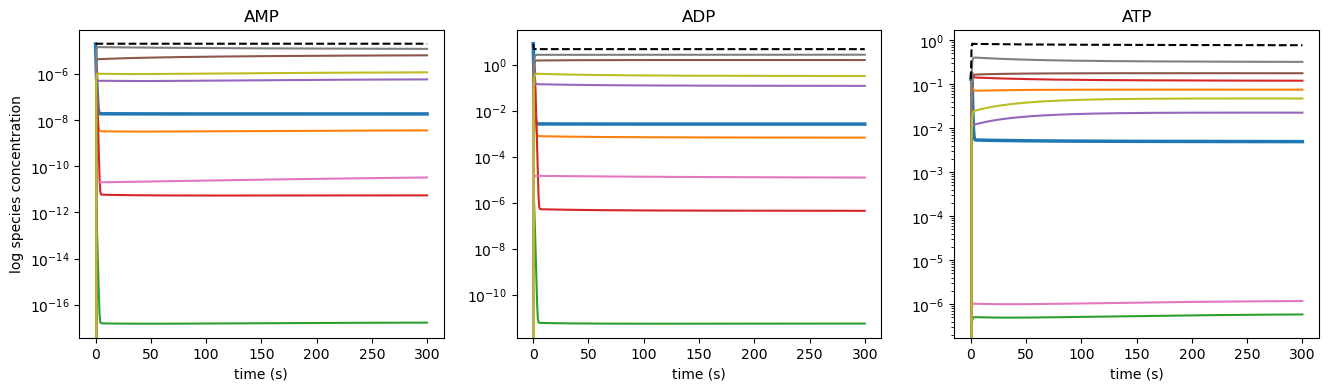

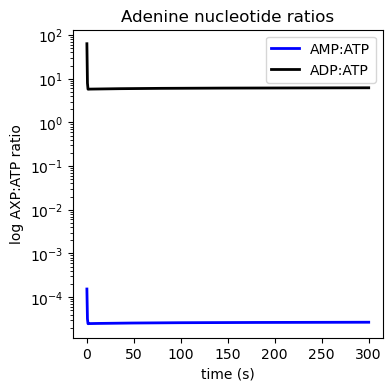

In [11]:
# Metabolism plots
fig0, ax0 = plt.subplots(1,3, figsize=(16,4))
# AMP
# plot [AMP] with thicker line
ax0[0].plot(tvals, yout.view(problem.state_dtype)['AMP'], linewidth=2.5)
AMPtot = yout.view(problem.state_dtype)['AMP']
# everything else
states_to_plot = ['AMP_AMPK', 'AMP_AMP_AMPK', 'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 
                  'AMP_pAMPK', 'AMP_AMP_pAMPK', 'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK']
for state in states_to_plot:
    ax0[0].plot(tvals, yout.view(problem.state_dtype)[state])
    AMPtot += yout.view(problem.state_dtype)[state]
# all AMP-x complexes
ax0[0].plot(tvals, AMPtot, 'k--')
# formatting
ax0[0].set_yscale('log')
ax0[0].set_ylabel('log species concentration')
ax0[0].set_xlabel('time (s)')
ax0[0].set_title('AMP')
# ADP
# plot [ADP] with thicker line
ax0[1].plot(tvals, yout.view(problem.state_dtype)['ADP'], linewidth=2.5)
ADPtot = yout.view(problem.state_dtype)['ADP']
# everything else
states_to_plot = ['ADP_AMPK', 'AMP_ADP_AMPK', 'ADP_ADP_AMPK', 'ADP_ATP_AMPK', 
                  'ADP_pAMPK', 'AMP_ADP_pAMPK', 'ADP_ADP_pAMPK', 'ADP_ATP_pAMPK']
for state in states_to_plot:
    ax0[1].plot(tvals, yout.view(problem.state_dtype)[state])
    ADPtot += yout.view(problem.state_dtype)[state]
# all ADP-x complexes
ax0[1].plot(tvals, ADPtot, 'k--')
# formatting
ax0[1].set_yscale('log')
ax0[1].set_xlabel('time (s)')
ax0[1].set_title('ADP')
# ATP
# plot [ADP] with thicker line
ax0[2].plot(tvals, yout.view(problem.state_dtype)['ATP'], linewidth=2.5)
ATPtot = yout.view(problem.state_dtype)['ATP']
# everything else
states_to_plot = ['ATP_AMPK', 'AMP_ATP_AMPK', 'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 
                  'ATP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ATP_pAMPK', 'ATP_ATP_pAMPK']
for state in states_to_plot:
    ax0[2].plot(tvals, yout.view(problem.state_dtype)[state])
    ATPtot += yout.view(problem.state_dtype)[state]
# all ATP-x complexes
ax0[2].plot(tvals, ATPtot, 'k--')
# formatting
ax0[2].set_yscale('log')
ax0[2].set_xlabel('time (s)')
ax0[2].set_title('ATP')

fig1, ax1 = plt.subplots(1,1, figsize=(4,4))
AMP_ATP_ratio = yout.view(problem.state_dtype)['AMP'] / yout.view(problem.state_dtype)['ATP']
ADP_ATP_ratio = yout.view(problem.state_dtype)['ADP'] / yout.view(problem.state_dtype)['ATP']
ax1.plot(tvals, AMP_ATP_ratio, 'b', linewidth=2)
ax1.plot(tvals, ADP_ATP_ratio, 'k', linewidth=2)
ax1.set_yscale('log')
ax1.set_ylabel('log AXP:ATP ratio')
ax1.set_xlabel('time (s)')
ax1.legend(('AMP:ATP', 'ADP:ATP'))
ax1.set_title('Adenine nucleotide ratios')

Text(0.5, 1.0, 'AMPK')

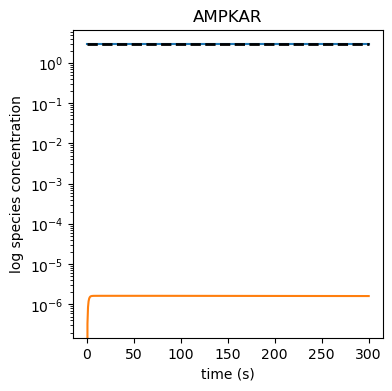

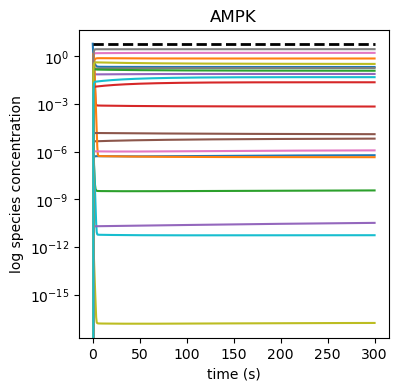

In [12]:
# Conserved quantities
# AMPKAR
states_to_plot = ['AMPKAR', 'pAMPKAR']
fig4, ax4 = plt.subplots(1,1, figsize=(4,4))
AMPKARtot = np.zeros(yout.view(problem.state_dtype)['AMPKAR'].shape)
for state in states_to_plot:
    AMPKARtot += yout.view(problem.state_dtype)[state]
    ax4.plot(tvals, yout.view(problem.state_dtype)[state])
ax4.plot(tvals, AMPKARtot, 'k--', linewidth=2)
ax4.set_yscale('log')
ax4.set_ylabel('log species concentration')
ax4.set_xlabel('time (s)')
ax4.set_title('AMPKAR')

# AMPK
states_to_plot = ['AMPK', 'pAMPK', # uncomplexed
                  'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', # single complex
                  'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK',
                  'AMP_AMP_AMPK', 'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 'ADP_ADP_AMPK', # double complexes
                  'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 'AMP_AMP_pAMPK',
                  'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ADP_pAMPK',
                  'ADP_ATP_pAMPK', 'ATP_ATP_pAMPK']
fig5, ax5 = plt.subplots(1,1, figsize=(4,4))
AMPKtot = np.zeros(yout.view(problem.state_dtype)['AMPK'].shape)
for state in states_to_plot:
    AMPKtot += yout.view(problem.state_dtype)[state]
    ax5.plot(tvals, yout.view(problem.state_dtype)[state])
ax5.plot(tvals, AMPKtot, 'k--', linewidth=2)
ax5.set_yscale('log')
ax5.set_ylabel('log species concentration')
ax5.set_xlabel('time (s)')
ax5.set_title('AMPK')